This code work with the output from waste Yolo self trained model    
The mm detection was done in autoDL  
Training used dataset published by MM detection  
Path: '/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/RS_Waste/'  
Training output: 'Yolo_train4'  
Test ouput: 'Pre_Visual_yolo.csv'  

Code include:  
1. Pre_yolo: prepare lable to be Yolo formal  
2. Pre_yolo: Clip test visual data to 1024*1024 for Yolo detection (Then zip and upload to autoDL)   
3. Post_Yolo: Convert JPEG + CSV Back to GeoTIFF

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import rasterio
from rasterio.windows import Window
from rasterio.transform import from_origin

In [2]:
Base = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/'

pre = '20231130/'
post = '20240511/'

Yolo_test = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/RS_Waste/Yolo_test/'

# PCO label to Yolo

In [ ]:
pip install lxml
import os
import xml.etree.ElementTree as ET

In [ ]:
# 🔹 Define the class names **(Make sure these match your dataset)**
classes = ["domestic_garbage", "construction_waste", "agriculture_forestry", "disposed_garbage"]

# Function to convert Pascal VOC bbox format to YOLO format
def convert(size, box):
    dw = 1. / size[0]
    dh = 1. / size[1]
    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w = box[1] - box[0]
    h = box[3] - box[2]
    x = x * dw
    w = w * dw
    y = y * dh
    h = h * dh
    return (x, y, w, h)

# Process a single XML file and convert to YOLO format
def process_xml(xml_path, save_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find('size')
    w = int(size.find('width').text)
    h = int(size.find('height').text)

    txt_file = os.path.join(save_path, os.path.basename(xml_path).replace('.xml', '.txt'))
    with open(txt_file, "w") as f_txt:
        for obj in root.iter('object'):
            # 🔹 Extract class name and replace spaces with underscores
            cls = obj.find('name').text.strip().replace(" ", "_")  
            
            if cls not in classes:
                print(f"⚠️ Warning: Class '{cls}' not in predefined list. Skipping.")
                continue  # Skip unknown classes
            
            cls_id = classes.index(cls)  # Convert class name to class index

            xmlbox = obj.find('bndbox')
            b = (float(xmlbox.find('xmin').text), float(xmlbox.find('xmax').text),
                 float(xmlbox.find('ymin').text), float(xmlbox.find('ymax').text))
            bb = convert((w, h), b)
            f_txt.write(f"{cls_id} " + " ".join(map(str, bb)) + '\n')

# 🔹 Convert all XML files in the folder
xml_folder = "/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/RS_Waste/VOC2012/test/Annotations/"  # Folder containing XML files
txt_folder = "/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/RS_Waste/VOC2012/train/yolo/"  # Folder to save YOLO txt files

if not os.path.exists(txt_folder):
    os.makedirs(txt_folder)

for xml_file in os.listdir(xml_folder):
    if xml_file.endswith(".xml"):
        process_xml(os.path.join(xml_folder, xml_file), txt_folder)

print("✅ Conversion complete! Check the 'labels' folder for YOLO format files.")

# Clip Visual data to 1024 for Yolo detection 

In [3]:
import rasterio
from rasterio.windows import Window
from rasterio.transform import from_origin
import numpy as np
import pandas as pd
from PIL import Image
import os
from tqdm import tqdm

In [4]:
Base = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/'

pre = '20231130/'
post = '20240511/'

Yolo_test = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/RS_Waste/Yolo_test/'

In [3]:
# Input and output paths
input_tif = Base + pre + "Visual_merged.tif"  # Replace with your actual file
output_folder = Base + pre + "Visual_out/"
metadata_csv = Base + pre + "Visual_merged.csv"

os.makedirs(output_folder, exist_ok=True)

# Create a list to store metadata
metadata = []

# Open the raster
with rasterio.open(input_tif) as src:
    width, height = src.width, src.height
    tile_size = 1024  # Tile size in pixels

    # Loop through raster in 1024x1024 non-overlapping tiles
    for i, y in enumerate(tqdm(range(0, height, tile_size), desc="Processing Rows")):
        for j, x in enumerate(tqdm(range(0, width, tile_size), desc=f"Processing Columns in row {i}", leave=False)):
            # Ensure we don't exceed bounds
            w = min(tile_size, width - x)
            h = min(tile_size, height - y)

            # Define the window for the tile
            window = Window(x, y, w, h)
            tile_data = src.read(window=window)

            # Compute new transform for the tile
            new_transform = from_origin(
                src.transform.c + x * src.transform.a,  # Left (X) coordinate
                src.transform.f + y * src.transform.e,  # Top (Y) coordinate
                src.transform.a,  # Pixel width
                src.transform.e,  # Pixel height
            )

            # Normalize tile data for visualization (0-255 range)
            tile_data = np.moveaxis(tile_data, 0, -1)  # Move channels to last axis
            tile_data = ((tile_data - tile_data.min()) / (tile_data.max() - tile_data.min()) * 255).astype(np.uint8)

            # Save as JPEG (for YOLO processing)
            tile_filename = f"tile_{i}_{j}.jpg"
            tile_path = os.path.join(output_folder, tile_filename)
            img = Image.fromarray(tile_data)
            img.save(tile_path)

            # Store metadata
            metadata.append({
                "tile_id": f"{i}_{j}",
                "filename": tile_filename,
                "x_offset": x,
                "y_offset": y,
                "width": w,
                "height": h,
                "left": new_transform.c,  # Left coordinate
                "top": new_transform.f,   # Top coordinate
                "pixel_size_x": new_transform.a,
                "pixel_size_y": new_transform.e,
                "crs": src.crs.to_string()  # Store CRS
            })

# Save metadata to CSV
df_metadata = pd.DataFrame(metadata)
df_metadata.to_csv(metadata_csv, index=False)

print(f"All tiles saved in {output_folder}, and metadata saved in {metadata_csv}")


Processing Columns in row 0:   0%|                       | 0/44 [00:00<?, ?it/s]/var/folders/2_/nk9j6sb901n_fk5dz_9vtqj80000gn/T/ipykernel_33580/1203486871.py:37: RuntimeWarning: invalid value encountered in divide
  tile_data = ((tile_data - tile_data.min()) / (tile_data.max() - tile_data.min()) * 255).astype(np.uint8)
/var/folders/2_/nk9j6sb901n_fk5dz_9vtqj80000gn/T/ipykernel_33580/1203486871.py:37: RuntimeWarning: invalid value encountered in cast
  tile_data = ((tile_data - tile_data.min()) / (tile_data.max() - tile_data.min()) * 255).astype(np.uint8)

Processing Rows: 100%|██████████████████████████| 79/79 [01:34<00:00,  1.20s/it]


All tiles saved in /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/Visual_out/, and metadata saved in /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/Visual_merged.csv


# Image: Generate bounding box for outputs

In [9]:
import os
import pandas as pd
import ast
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load the CSV and filter out rows where yolo_num is 0
df = pd.read_csv(Yolo_test + 'Pre_Visual_yolo.csv')
df = df[df["yolo_num"] > 0]

# Directory where images are stored
image_dir = Base + pre + "/Visual_out"  # Change this to your actual image directory
output_dir = Yolo_test + "visualized_tiles/"  # Directory to save annotated images
os.makedirs(output_dir, exist_ok=True)

## Only domestic waste

In [4]:
# Function to draw bounding boxes only for 'domestic_garbage'
def draw_bboxes(image_path, bboxes, confidences, labels, output_path):
    image = Image.open(image_path)
    draw = ImageDraw.Draw(image)
    
    try:
        font = ImageFont.truetype("arial.ttf", 40)  # Use larger font
    except:
        font = ImageFont.load_default()  # Fallback to default if Arial is not found

    domestic_found = False  # Flag to check if at least one domestic_garbage box exists

    for bbox, conf, label in zip(bboxes, confidences, labels):
        if label != "domestic_garbage":
            continue  # Skip non-domestic detections

        domestic_found = True  # Mark that we found a domestic_garbage detection
        x_min, y_min, x_max, y_max = bbox
        draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=3)
        draw.text((x_min, y_min - 10), f"{label} {conf:.2f}", fill="red", font=font)

    if domestic_found:  # Only save if at least one domestic_garbage box is found
        image.save(output_path)
        return True  # Image was saved
    return False  # Image was skipped

# Iterate through the DataFrame and process each image
for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing Images"):
    image_path = os.path.join(image_dir, row["filename"])
    output_path = os.path.join(output_dir, row["filename"])
    
    # Convert bounding boxes, confidence scores, and labels from string to list
    bboxes = ast.literal_eval(row["yolo_bbox"])  # Bounding boxes
    confidences = ast.literal_eval(row["yolo_conf"])  # Confidence scores
    labels = ast.literal_eval(row["yolo_labels"])  # Detection labels
    
    # Draw bounding boxes only for domestic_garbage
    image_saved = draw_bboxes(image_path, bboxes, confidences, labels, output_path)
    
    # if not image_saved:
        # print(f"Skipped {row['filename']} (no domestic_garbage detected)")

print("Bounding box drawing complete. Only images with domestic waste were saved.")


Processing Images: 100%|███████████████████| 1431/1431 [00:11<00:00, 120.52it/s]

Bounding box drawing complete. Only images with domestic waste were saved.


## All class with different color

In [10]:
# Define color mapping for different classes
color_mapping = {
    "domestic_garbage": "red",
    "agriculture_forestry": "green",
    "construction_waste": "gray"
}

# Function to draw bounding boxes on images
def draw_bboxes(image_path, bboxes, confidences, labels, output_path):
    image = Image.open(image_path)
    draw = ImageDraw.Draw(image)
    font = ImageFont.load_default()
    
    for bbox, conf, label in zip(bboxes, confidences, labels):
        x_min, y_min, x_max, y_max = bbox
        color = color_mapping.get(label, "blue")  # Default to blue if unknown label
        draw.rectangle([x_min, y_min, x_max, y_max], outline=color, width=3)
        draw.text((x_min, y_min - 10), f"{label} {conf:.2f}", fill=color, font=font)
    
    image.save(output_path)
    return image

# Iterate through the DataFrame and process each image
for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing Images"):
    image_path = os.path.join(image_dir, row["filename"])
    output_path = os.path.join(output_dir, row["filename"])
    
    # Convert bounding boxes, confidence scores, and labels from string to list
    bboxes = ast.literal_eval(row["yolo_bbox"])  # Bounding boxes
    confidences = ast.literal_eval(row["yolo_conf"])  # Confidence scores
    labels = ast.literal_eval(row["yolo_labels"])  # Detection labels
    
    # Draw bounding boxes with corresponding labels
    annotated_image = draw_bboxes(image_path, bboxes, confidences, labels, output_path)

print("Bounding box drawing complete. Annotated images saved in", output_dir)


Processing Images: 100%|███████████████████| 1431/1431 [00:11<00:00, 123.20it/s]

Bounding box drawing complete. Annotated images saved in /Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/RS_Waste/Yolo_test/visualized_tiles/


# Image: Convert JPEG + CSV Back to GeoTIFF

In [11]:
import rasterio
from rasterio.transform import from_origin
import pandas as pd
import numpy as np
from PIL import Image
import os
from tqdm import tqdm

# Paths
metadata_csv = Base + pre + "Visual_meta.csv"  # Metadata CSV
selected_folder = Yolo_test + "visualized_tiles/"  # Folder containing the images to be processed
# output_folder = Yolo_test + "Yolo_re_domestic/"  # Folder for reconstructed GeoTIFFs
output_folder = Yolo_test + "Yolo_re_all/"  # Folder for reconstructed GeoTIFFs

os.makedirs(output_folder, exist_ok=True)

In [12]:
# Load metadata
df_metadata = pd.read_csv(metadata_csv)

# Get list of filenames in the selected folder
selected_files = set(os.listdir(selected_folder))

# Filter metadata to only include selected images
df_metadata = df_metadata[df_metadata["filename"].isin(selected_files)]

# Loop through filtered metadata and reconstruct GeoTIFFs
for _, row in tqdm(df_metadata.iterrows(), total=len(df_metadata), desc="Reconstructing GeoTIFFs"):
    tile_filename = row["filename"]
    tile_path = os.path.join(selected_folder, tile_filename)  # Full path to JPEG

    if not os.path.exists(tile_path):
        print(f"Warning: {tile_path} not found. Skipping.")
        continue

    # Open the JPEG image
    img = Image.open(tile_path)
    img_array = np.array(img)

    # Convert grayscale/single-channel images to 3-band RGB (if needed)
    if img_array.ndim == 2:
        img_array = np.stack([img_array] * 3, axis=-1)

    # Extract geospatial information
    new_transform = from_origin(
        row["left"], row["top"],
        row["pixel_size_x"], row["pixel_size_y"]
    )
    
    # Define output path for reconstructed GeoTIFF
    output_tif_path = os.path.join(output_folder, tile_filename.replace(".jpg", ".tif"))

    # Save as a GeoTIFF
    with rasterio.open(
        output_tif_path, "w",
        driver="GTiff",
        height=img_array.shape[0],
        width=img_array.shape[1],
        count=3,  # RGB bands
        dtype=img_array.dtype,
        crs=row["crs"],  # Coordinate reference system
        transform=new_transform
    ) as dst:
        for band in range(3):  # Save each color band
            dst.write(img_array[:, :, band], band + 1)

print("Selected JPEG images have been converted back to GeoTIFFs!")

Reconstructing GeoTIFFs: 100%|██████████████| 1431/1431 [00:16<00:00, 85.51it/s]

Selected JPEG images have been converted back to GeoTIFFs!


# .csv: Get detected vector

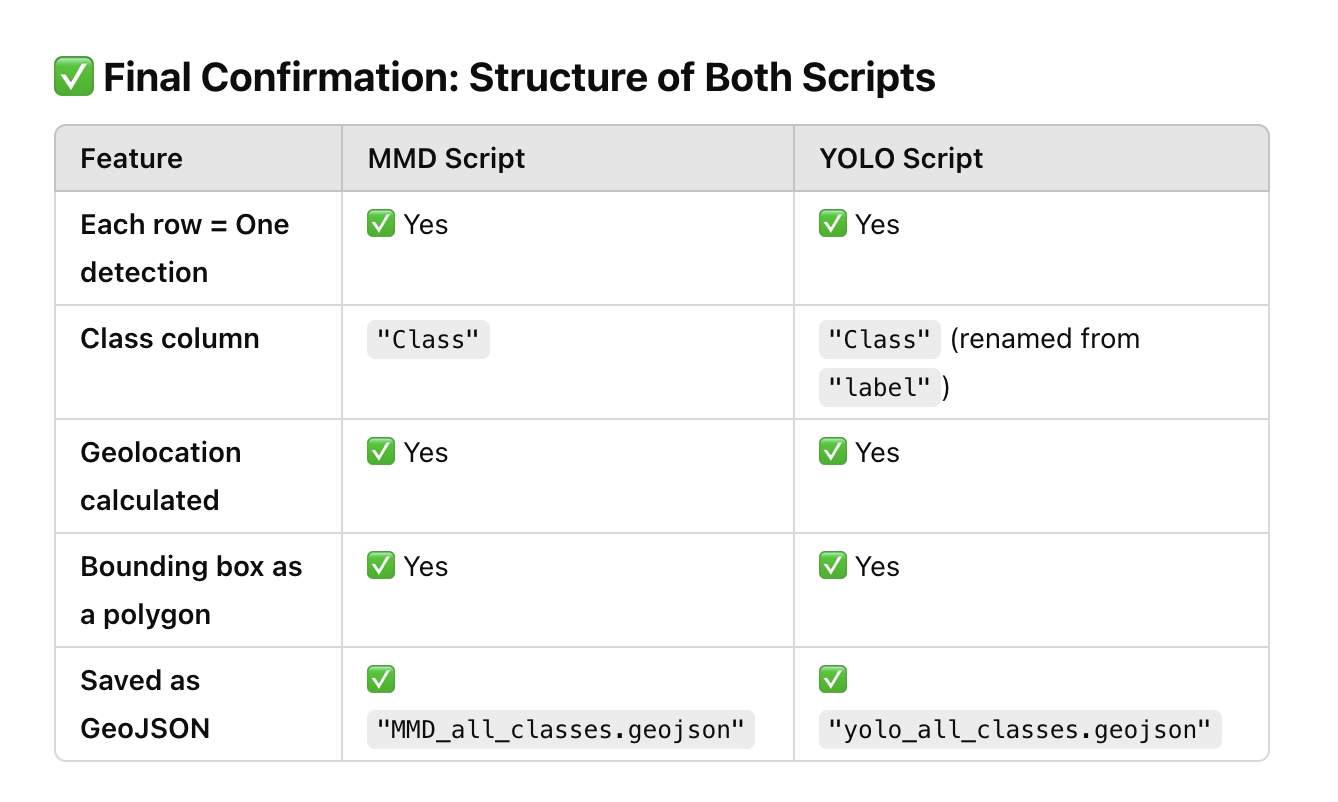

In [4]:
import pandas as pd
import geopandas as gpd
import ast
from shapely.geometry import Polygon

# Load YOLO detection CSV
yolo_df = pd.read_csv(Yolo_test + "Pre_Visual_yolo.csv")

# Ensure correct column names (strip spaces if needed)
yolo_df.columns = yolo_df.columns.str.strip()

# Convert string lists to actual lists (if stored as text)
yolo_df["yolo_bbox"] = yolo_df["yolo_bbox"].apply(ast.literal_eval)
yolo_df["yolo_labels"] = yolo_df["yolo_labels"].apply(ast.literal_eval)
yolo_df

,tile_id,filename,x_offset,y_offset,width,height,left,top,pixel_size_x,pixel_size_y,crs,yolo_conf,yolo_bbox,yolo_num,yolo_cls,yolo_labels
0,0_0,tile_0_0.jpg,0,0,1024,1024,253477.172852,9.872088e+06,0.305176,0.305176,EPSG:32737,[],[],0,[],[]
1,0_1,tile_0_1.jpg,1024,0,1024,1024,253789.672852,9.872088e+06,0.305176,0.305176,EPSG:32737,[],[],0,[],[]
2,0_2,tile_0_2.jpg,2048,0,1024,1024,254102.172852,9.872088e+06,0.305176,0.305176,EPSG:32737,[],[],0,[],[]
3,0_3,tile_0_3.jpg,3072,0,1024,1024,254414.672852,9.872088e+06,0.305176,0.305176,EPSG:32737,[],[],0,[],[]
4,0_4,tile_0_4.jpg,4096,0,1024,1024,254727.172852,9.872088e+06,0.305176,0.305176,EPSG:32737,[],[],0,[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3471,78_39,tile_78_39.jpg,39936,79872,1024,1023,265664.672852,9.847713e+06,0.305176,0.305176,EPSG:32737,[],[],0,[],[]
3472,78_40,tile_78_40.jpg,40960,79872,1024,1023,265977.172852,9.847713e+06,0.305176,0.305176,EPSG:32737,[],[],0,[],[]
3473,78_41,tile_78_41.jpg,41984,79872,1024,1023,266289.672852,9.847713e+06,0.305176,0.305176,EPSG:32737,[],[],0,[],[]
3474,78_42,tile_78_42.jpg,43008,79872,1024,1023,266602.172852,9.847713e+06,0.305176,0.305176,EPSG:32737,[],[],0,[],[]


In [5]:
# Expand YOLO bounding boxes into separate rows
expanded_rows = []
for _, row in yolo_df.iterrows():
    for bbox, label in zip(row["yolo_bbox"], row["yolo_labels"]):
        expanded_rows.append({
            "tile_id": row["tile_id"],
            "x_min": bbox[0],  # YOLO bbox format: [x_min, y_min, x_max, y_max]
            "y_min": bbox[1],
            "x_max": bbox[2],
            "y_max": bbox[3],
            "Class": label,  # ✅ Renamed to "Class" for consistency
            "confidence": row.get("yolo_conf", None),  # Optional: Store confidence scores
            "left": row["left"],  # Tile geolocation reference
            "top": row["top"],
            "pixel_size_x": row["pixel_size_x"],
            "pixel_size_y": row["pixel_size_y"],
            "crs": row["crs"]  # Store CRS for reference
        })

# Convert expanded list into a DataFrame
expanded_df = pd.DataFrame(expanded_rows)
expanded_df

,tile_id,x_min,y_min,x_max,y_max,Class,confidence,left,top,pixel_size_x,pixel_size_y,crs
0,0_17,342.991394,993.212585,390.590637,1021.183777,domestic_garbage,[0.3695739209651947],258789.672852,9.872088e+06,0.305176,0.305176,EPSG:32737
1,0_19,341.606873,922.483704,375.389771,951.050964,domestic_garbage,[0.6186270117759705],259414.672852,9.872088e+06,0.305176,0.305176,EPSG:32737
2,0_30,981.383911,708.084106,1024.000000,766.637817,agriculture_forestry,[0.37227150797843933],262852.172852,9.872088e+06,0.305176,0.305176,EPSG:32737
3,0_38,206.121277,729.019043,265.393738,785.973877,domestic_garbage,"[0.5572303533554077, 0.407908171415329]",265352.172852,9.872088e+06,0.305176,0.305176,EPSG:32737
4,0_38,206.410614,728.446655,266.429108,786.182373,agriculture_forestry,"[0.5572303533554077, 0.407908171415329]",265352.172852,9.872088e+06,0.305176,0.305176,EPSG:32737
...,...,...,...,...,...,...,...,...,...,...,...,...
2115,78_11,158.554016,477.320251,213.033386,508.625183,domestic_garbage,"[0.5804091691970825, 0.4932415187358856]",256914.672852,9.847713e+06,0.305176,0.305176,EPSG:32737
2116,78_25,882.491455,422.819244,924.723633,457.530060,domestic_garbage,[0.3696348965167999],261289.672852,9.847713e+06,0.305176,0.305176,EPSG:32737
2117,78_29,727.310303,327.610992,752.186768,350.046967,domestic_garbage,[0.29445406794548035],262539.672852,9.847713e+06,0.305176,0.305176,EPSG:32737
2118,78_34,864.212891,14.014679,1011.132812,387.177948,domestic_garbage,[0.41146621108055115],264102.172852,9.847713e+06,0.305176,0.305176,EPSG:32737


In [6]:
# Function to create polygons
def create_polygon(row):
    try:
        polygon = Polygon([
            (row["global_x_min"], row["global_y_min"]),
            (row["global_x_max"], row["global_y_min"]),
            (row["global_x_max"], row["global_y_max"]),
            (row["global_x_min"], row["global_y_max"]),
            (row["global_x_min"], row["global_y_min"])  # Closing the polygon
        ])
        return polygon if polygon.is_valid else None
    except Exception as e:
        print(f"Error creating polygon for row {row.name}: {e}")
        return None

## Only for Domestic 

In [9]:
# **Filter only "domestic garbage" detections**
domestic_df = expanded_df[expanded_df["Class"] == "domestic_garbage"].copy()

# Compute real-world geolocation of bounding box coordinates
domestic_df["global_x_min"] = domestic_df["left"] + (domestic_df["x_min"] * domestic_df["pixel_size_x"])
domestic_df["global_y_min"] = domestic_df["top"] - (domestic_df["y_min"] * domestic_df["pixel_size_y"])
domestic_df["global_x_max"] = domestic_df["left"] + (domestic_df["x_max"] * domestic_df["pixel_size_x"])
domestic_df["global_y_max"] = domestic_df["top"] - (domestic_df["y_max"] * domestic_df["pixel_size_y"])

# Debug: Print transformed coordinates for verification
# print(domestic_df[["tile_id", "Class", "global_x_min", "global_y_min", "global_x_max", "global_y_max"]].head())
domestic_df

,tile_id,x_min,y_min,x_max,y_max,Class,confidence,left,top,pixel_size_x,pixel_size_y,crs,global_x_min,global_y_min,global_x_max,global_y_max,geometry
0,0_17,342.991394,993.212585,390.590637,1021.183777,domestic_garbage,[0.3695739209651947],258789.672852,9.872088e+06,0.305176,0.305176,EPSG:32737,258894.345518,9.871785e+06,258908.871654,9.871777e+06,"POLYGON ((258894.3455182016 9871785.213444382,..."
1,0_19,341.606873,922.483704,375.389771,951.050964,domestic_garbage,[0.6186270117759705],259414.672852,9.872088e+06,0.305176,0.305176,EPSG:32737,259518.922996,9.871807e+06,259529.232718,9.871798e+06,POLYGON ((259518.92299577594 9871806.798186153...
3,0_38,206.121277,729.019043,265.393738,785.973877,domestic_garbage,"[0.5572303533554077, 0.407908171415329]",265352.172852,9.872088e+06,0.305176,0.305176,EPSG:32737,265415.076073,9.871866e+06,265433.164593,9.871848e+06,"POLYGON ((265415.0760732591 9871865.83891511, ..."
5,0_40,642.867920,198.485580,671.099243,227.414841,domestic_garbage,"[0.6150668859481812, 0.336372971534729]",265977.172852,9.872088e+06,0.305176,0.305176,EPSG:32737,266173.360571,9.872028e+06,266181.976087,9.872019e+06,"POLYGON ((266173.3605712652 9872027.744879015,..."
7,0_43,549.420532,940.909546,587.603149,975.149780,domestic_garbage,[0.3673587143421173],266914.672852,9.872088e+06,0.305176,0.305176,EPSG:32737,267082.342692,9.871801e+06,267093.995102,9.871791e+06,POLYGON ((267082.34269171953 9871801.175065339...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,78_11,158.554016,477.320251,213.033386,508.625183,domestic_garbage,"[0.5804091691970825, 0.4932415187358856]",256914.672852,9.847713e+06,0.305176,0.305176,EPSG:32737,256963.059697,9.847568e+06,256979.685482,9.847558e+06,"POLYGON ((256963.0596973002 9847567.651290447,..."
2116,78_25,882.491455,422.819244,924.723633,457.530060,domestic_garbage,[0.3696348965167999],261289.672852,9.847713e+06,0.305176,0.305176,EPSG:32737,261558.987871,9.847584e+06,261571.876109,9.847574e+06,POLYGON ((261558.98787081242 9847584.283677861...
2117,78_29,727.310303,327.610992,752.186768,350.046967,domestic_garbage,[0.29445406794548035],262539.672852,9.847713e+06,0.305176,0.305176,EPSG:32737,262761.630341,9.847613e+06,262769.222036,9.847606e+06,POLYGON ((262761.63034141064 9847613.338930532...
2118,78_34,864.212891,14.014679,1011.132812,387.177948,domestic_garbage,[0.41146621108055115],264102.172852,9.847713e+06,0.305176,0.305176,EPSG:32737,264365.909696,9.847709e+06,264410.746098,9.847595e+06,"POLYGON ((264365.9096956253 9847709.040930495,..."


In [10]:
# Apply function to create geometry
domestic_df["geometry"] = domestic_df.apply(create_polygon, axis=1)

# Drop invalid geometries
domestic_df = domestic_df.dropna(subset=["geometry"])

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(domestic_df, geometry="geometry", crs="EPSG:32737")

# Save as GeoJSON for GIS visualization
gdf.to_file(Yolo_test + "yolo_domestic_garbage.geojson", driver="GeoJSON")

print("✅ YOLO Domestic Garbage detections saved successfully!")
gdf

✅ YOLO Domestic Garbage detections saved successfully!


,tile_id,x_min,y_min,x_max,y_max,Class,confidence,left,top,pixel_size_x,pixel_size_y,crs,global_x_min,global_y_min,global_x_max,global_y_max,geometry
0,0_17,342.991394,993.212585,390.590637,1021.183777,domestic_garbage,[0.3695739209651947],258789.672852,9.872088e+06,0.305176,0.305176,EPSG:32737,258894.345518,9.871785e+06,258908.871654,9.871777e+06,"POLYGON ((258894.346 9871785.213, 258908.872 9..."
1,0_19,341.606873,922.483704,375.389771,951.050964,domestic_garbage,[0.6186270117759705],259414.672852,9.872088e+06,0.305176,0.305176,EPSG:32737,259518.922996,9.871807e+06,259529.232718,9.871798e+06,"POLYGON ((259518.923 9871806.798, 259529.233 9..."
3,0_38,206.121277,729.019043,265.393738,785.973877,domestic_garbage,"[0.5572303533554077, 0.407908171415329]",265352.172852,9.872088e+06,0.305176,0.305176,EPSG:32737,265415.076073,9.871866e+06,265433.164593,9.871848e+06,"POLYGON ((265415.076 9871865.839, 265433.165 9..."
5,0_40,642.867920,198.485580,671.099243,227.414841,domestic_garbage,"[0.6150668859481812, 0.336372971534729]",265977.172852,9.872088e+06,0.305176,0.305176,EPSG:32737,266173.360571,9.872028e+06,266181.976087,9.872019e+06,"POLYGON ((266173.361 9872027.745, 266181.976 9..."
7,0_43,549.420532,940.909546,587.603149,975.149780,domestic_garbage,[0.3673587143421173],266914.672852,9.872088e+06,0.305176,0.305176,EPSG:32737,267082.342692,9.871801e+06,267093.995102,9.871791e+06,"POLYGON ((267082.343 9871801.175, 267093.995 9..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,78_11,158.554016,477.320251,213.033386,508.625183,domestic_garbage,"[0.5804091691970825, 0.4932415187358856]",256914.672852,9.847713e+06,0.305176,0.305176,EPSG:32737,256963.059697,9.847568e+06,256979.685482,9.847558e+06,"POLYGON ((256963.060 9847567.651, 256979.685 9..."
2116,78_25,882.491455,422.819244,924.723633,457.530060,domestic_garbage,[0.3696348965167999],261289.672852,9.847713e+06,0.305176,0.305176,EPSG:32737,261558.987871,9.847584e+06,261571.876109,9.847574e+06,"POLYGON ((261558.988 9847584.284, 261571.876 9..."
2117,78_29,727.310303,327.610992,752.186768,350.046967,domestic_garbage,[0.29445406794548035],262539.672852,9.847713e+06,0.305176,0.305176,EPSG:32737,262761.630341,9.847613e+06,262769.222036,9.847606e+06,"POLYGON ((262761.630 9847613.339, 262769.222 9..."
2118,78_34,864.212891,14.014679,1011.132812,387.177948,domestic_garbage,[0.41146621108055115],264102.172852,9.847713e+06,0.305176,0.305176,EPSG:32737,264365.909696,9.847709e+06,264410.746098,9.847595e+06,"POLYGON ((264365.910 9847709.041, 264410.746 9..."


## All Detect result 

In [ ]:
# import pandas as pd
# import geopandas as gpd
# import ast
# from shapely.geometry import Polygon

# # Load YOLO detection CSV
# yolo_df = pd.read_csv(Yolo_test + "Pre_Visual_yolo.csv")

# # Ensure correct column names (strip spaces if needed)
# yolo_df.columns = yolo_df.columns.str.strip()

# # Convert string lists to actual lists (if stored as text)
# yolo_df["yolo_bbox"] = yolo_df["yolo_bbox"].apply(ast.literal_eval)
# yolo_df["yolo_labels"] = yolo_df["yolo_labels"].apply(ast.literal_eval)

# # Expand YOLO bounding boxes into separate rows
# expanded_rows = []
# for _, row in yolo_df.iterrows():
#     for bbox, label in zip(row["yolo_bbox"], row["yolo_labels"]):
#         expanded_rows.append({
#             "tile_id": row["tile_id"],
#             "x_min": bbox[0],  # YOLO bbox format: [x_min, y_min, x_max, y_max]
#             "y_min": bbox[1],
#             "x_max": bbox[2],
#             "y_max": bbox[3],
#             "Class": label,  # ✅ Renamed from "label" to "Class" for consistency with MMD
#             "confidence": row.get("yolo_conf", None),  # Optional: Store confidence scores
#             "left": row["left"],  # Tile geolocation reference
#             "top": row["top"],
#             "pixel_size_x": row["pixel_size_x"],
#             "pixel_size_y": row["pixel_size_y"],
#             "crs": row["crs"]  # Store CRS for reference
#         })

In [11]:
# # Convert expanded list into a DataFrame
# expanded_df = pd.DataFrame(expanded_rows)

# Compute real-world geolocation of bounding box coordinates
expanded_df["global_x_min"] = expanded_df["left"] + (expanded_df["x_min"] * expanded_df["pixel_size_x"])
expanded_df["global_y_min"] = expanded_df["top"] - (expanded_df["y_min"] * expanded_df["pixel_size_y"])
expanded_df["global_x_max"] = expanded_df["left"] + (expanded_df["x_max"] * expanded_df["pixel_size_x"])
expanded_df["global_y_max"] = expanded_df["top"] - (expanded_df["y_max"] * expanded_df["pixel_size_y"])

# # Debug: Print transformed coordinates for verification
# print(expanded_df[["tile_id", "Class", "global_x_min", "global_y_min", "global_x_max", "global_y_max"]].head())

# Function to create polygons
def create_polygon(row):
    try:
        polygon = Polygon([
            (row["global_x_min"], row["global_y_min"]),
            (row["global_x_max"], row["global_y_min"]),
            (row["global_x_max"], row["global_y_max"]),
            (row["global_x_min"], row["global_y_max"]),
            (row["global_x_min"], row["global_y_min"])  # Closing the polygon
        ])
        return polygon if polygon.is_valid else None
    except Exception as e:
        print(f"Error creating polygon for row {row.name}: {e}")
        return None

# Apply function to create geometry
expanded_df["geometry"] = expanded_df.apply(create_polygon, axis=1)

# Drop invalid geometries
expanded_df = expanded_df.dropna(subset=["geometry"])

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(expanded_df, geometry="geometry", crs="EPSG:32737")

# Save as GeoJSON for GIS visualization
gdf.to_file(Yolo_test + "yolo_all_classes.geojson", driver="GeoJSON")

print("✅ YOLO all classes saved successfully as a GeoJSON!")

gdf

✅ YOLO all classes saved successfully as a GeoJSON!


,tile_id,x_min,y_min,x_max,y_max,Class,confidence,left,top,pixel_size_x,pixel_size_y,crs,global_x_min,global_y_min,global_x_max,global_y_max,geometry
0,0_17,342.991394,993.212585,390.590637,1021.183777,domestic_garbage,[0.3695739209651947],258789.672852,9.872088e+06,0.305176,0.305176,EPSG:32737,258894.345518,9.871785e+06,258908.871654,9.871777e+06,"POLYGON ((258894.346 9871785.213, 258908.872 9..."
1,0_19,341.606873,922.483704,375.389771,951.050964,domestic_garbage,[0.6186270117759705],259414.672852,9.872088e+06,0.305176,0.305176,EPSG:32737,259518.922996,9.871807e+06,259529.232718,9.871798e+06,"POLYGON ((259518.923 9871806.798, 259529.233 9..."
2,0_30,981.383911,708.084106,1024.000000,766.637817,agriculture_forestry,[0.37227150797843933],262852.172852,9.872088e+06,0.305176,0.305176,EPSG:32737,263151.667453,9.871872e+06,263164.672852,9.871854e+06,"POLYGON ((263151.667 9871872.228, 263164.673 9..."
3,0_38,206.121277,729.019043,265.393738,785.973877,domestic_garbage,"[0.5572303533554077, 0.407908171415329]",265352.172852,9.872088e+06,0.305176,0.305176,EPSG:32737,265415.076073,9.871866e+06,265433.164593,9.871848e+06,"POLYGON ((265415.076 9871865.839, 265433.165 9..."
4,0_38,206.410614,728.446655,266.429108,786.182373,agriculture_forestry,"[0.5572303533554077, 0.407908171415329]",265352.172852,9.872088e+06,0.305176,0.305176,EPSG:32737,265415.164372,9.871866e+06,265433.480563,9.871848e+06,"POLYGON ((265415.164 9871866.014, 265433.481 9..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,78_11,158.554016,477.320251,213.033386,508.625183,domestic_garbage,"[0.5804091691970825, 0.4932415187358856]",256914.672852,9.847713e+06,0.305176,0.305176,EPSG:32737,256963.059697,9.847568e+06,256979.685482,9.847558e+06,"POLYGON ((256963.060 9847567.651, 256979.685 9..."
2116,78_25,882.491455,422.819244,924.723633,457.530060,domestic_garbage,[0.3696348965167999],261289.672852,9.847713e+06,0.305176,0.305176,EPSG:32737,261558.987871,9.847584e+06,261571.876109,9.847574e+06,"POLYGON ((261558.988 9847584.284, 261571.876 9..."
2117,78_29,727.310303,327.610992,752.186768,350.046967,domestic_garbage,[0.29445406794548035],262539.672852,9.847713e+06,0.305176,0.305176,EPSG:32737,262761.630341,9.847613e+06,262769.222036,9.847606e+06,"POLYGON ((262761.630 9847613.339, 262769.222 9..."
2118,78_34,864.212891,14.014679,1011.132812,387.177948,domestic_garbage,[0.41146621108055115],264102.172852,9.847713e+06,0.305176,0.305176,EPSG:32737,264365.909696,9.847709e+06,264410.746098,9.847595e+06,"POLYGON ((264365.910 9847709.041, 264410.746 9..."
